# 06_特征选择方法-单变量特征选择

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇使用代码生成的模拟数据或 scikit-learn 随包附带的小数据集，无需外部数据文件。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


本文给大家讲解一下特征选择方法中的单变量特征选择\~

单变量特征选择是一种在机器学习中用来选择最相关特征的方法。你可以把“特征”理解成数据中的不同部分，比如在预测房价的任务中，特征可能是“房子的面积”、“位置”、“楼层”等。

单变量特征选择的核心思想是，**通过查看每个特征与目标变量（你想预测的结果）之间的关系，来决定哪个特征最重要**。目标是去掉那些跟结果没有太大关系的特征，只保留那些能帮助你做预测的特征。

### 举个简单的例子：

假设你想根据房子的“面积”和“房龄”来预测房价。你可以用单变量特征选择的方法来检查“面积”和“房龄”这两个特征，看看哪个对预测房价的影响更大。如果“面积”和“房价”之间有很强的关系（比如面积越大，房价越高），而“房龄”和房价之间的关系较弱（即房龄对房价影响不大），那么单变量特征选择可能会把“房龄”这个特征去掉，只保留“面积”。

### 操作步骤：

1. **计算每个特征与目标变量之间的关系**：比如使用统计测试，评估每个特征与目标之间的相关性。
2. **选择最相关的特征**：根据评估的结果，选择那些与目标变量有强相关性的特征。
3. **去掉不相关的特征**：把与目标变量关系不大的特征去掉，留下对预测有用的特征。

### 常用方法：

- **卡方检验**：用于分类问题，判断特征与目标分类变量之间的独立性。
- **F检验**：用于评估连续特征与目标变量之间的相关性。
- **互信息**：衡量特征与目标之间的相互依赖程度。

单变量特征选择就是一种通过统计方法来筛选出对预测最有用的特征的过程，它通过分析每个特征与目标变量的关系，去除那些不重要的特征，从而简化模型、提高效率。对于刚刚接触的同学来说，可以把它当作“挑选最关键的输入变量来帮助做出更准确的预测”的过程。

## 原理详解

单变量特征选择的核心思想是根据每个特征与目标变量之间的统计关系，来选择最相关的特征。常见的方法包括卡方检验、F检验和互信息。

### 数学原理

单变量特征选择的目的是从所有特征中选择与目标变量关系最密切的特征。具体而言，我们关注每个特征与目标变量之间的依赖关系。常用的数学度量方法如下：

#### 1. 卡方检验

卡方检验是一种用于检验两个类别变量之间是否独立的统计方法。

在单变量特征选择中，卡方检验用于评估每个特征（通常是分类特征）与目标变量（通常也是分类特征）之间的关系强度。

##### 卡方统计量公式：

对于特征 $X$和目标变量 $Y$，卡方统计量的计算公式为：


$$
\chi^2 = \sum \frac{(O_{ij} - E_{ij})^2}{E_{ij}}
$$


其中：

$O_{ij}$是观察到的频率（即，实际数据中类别 $i$和 $j$的组合出现的频数）

$E_{ij}$是期望频率，基于总体分布的假设计算出来的频数

期望频率 $E_{ij}$可以通过以下公式计算：


$$
E_{ij} = \frac{( \text{row sum of } i ) \times (\text{column sum of } j)}{\text{total samples}}
$$


卡方统计量越大，表示该特征与目标变量之间的依赖关系越强，反之则表示其依赖关系越弱。

##### 选择标准：

卡方检验的输出是一个卡方统计量 $\chi^2$和相应的p值。通常，我们根据p值来判断特征是否重要。较小的p值表示特征与目标变量之间的关系显著。

#### 2. F检验

F检验常用于评估一个连续特征与目标变量之间的关系，通常用于单因素方差分析（ANOVA）。其目的是检验不同类别的均值是否有显著差异。

##### F检验的统计量公式：

假设我们有一个连续特征 $X$和一个分类目标变量 $Y$，F检验的统计量计算公式为：


$$
F = \frac{\text{组间方差}}{\text{组内方差}}
$$


其中：

- 组间方差表示各类别之间的差异，可以通过类别均值与总均值的差异来计算：


$$
\text{组间方差} = \frac{\sum_{i=1}^{k} n_i (\bar{X_i} - \bar{X})^2}{k-1}
$$


- 其中，$k$是类别数，$n_i$是每个类别的样本数量，$\bar{X_i}$是第 $i$类别的均值，$\bar{X}$是总体均值。
- 组内方差表示各类别内部样本之间的差异：


$$
\text{组内方差} = \frac{\sum_{i=1}^{k} \sum_{j=1}^{n_i} (X_{ij} - \bar{X_i})^2}{N-k}
$$


- 其中，$X_{ij}$是第 $i$类别中第 $j$个样本的值，$\bar{X_i}$是第 $i$类别的均值，$N$是总样本数。

##### 选择标准：

F检验的输出是F统计量和p值。如果F值越大，表明组间差异越大，组内差异越小，从而说明该特征与目标变量的关系较强。通过p值判断显著性，通常p值小于某个阈值（如0.05）时，认为该特征显著。

#### 3. 互信息

互信息是衡量两个随机变量之间相互依赖程度的指标。对于单变量特征选择，互信息用于衡量特征 $X$与目标变量 $Y$之间的信息共享程度。

互信息 $I(X; Y)$由下式定义：


$$
I(X; Y) = \sum_{x \in X} \sum_{y \in Y} p(x, y) \log \frac{p(x, y)}{p(x) p(y)}
$$


其中：

- $p(x, y)$是特征 $X$和目标变量 $Y$同时取值为 $x$和 $y$的联合概率。
- $p(x)$和 $p(y)$分别是特征 $X$和目标变量 $Y$的边缘概率。

互信息越大，表示特征和目标之间的关系越强。

##### 选择标准：

通过计算互信息值，选择那些互信息值较大的特征。高互信息值意味着特征与目标变量之间有较强的关联性。

### 单变量特征选择的算法流程

1. **步骤1：数据预处理**

   - **检查数据的类型**：确定每个特征是连续型还是类别型，以选择合适的统计检验方法（卡方检验、F检验、互信息等）。
   - **处理缺失值**：对缺失的数据进行填补或删除。
   - **标准化数据**：如果使用F检验等方法，可能需要对数据进行标准化处理，尤其是连续特征。
2. **步骤2：计算统计量**

   - 对每个特征与目标变量计算统计量。
   
     - 对于分类特征，使用**卡方检验**。
     - 对于连续特征，使用**F检验**（ANOVA）。
     - 对于一般特征（无论是分类还是连续），使用**互信息**。
3. **步骤3：选择特征**

   - 根据计算出的统计量或p值选择最重要的特征。
   
     - 如果使用卡方检验或F检验，可以选择p值小于某一阈值（如0.05）的特征。
     - 如果使用互信息，选择互信息值较大的特征。
4. **步骤4：构建模型**

   - 使用选定的特征训练机器学习模型。
5. **步骤5：评估结果**

   - 评估模型的表现，看看去除不相关特征后的模型性能是否有所提升。

总的来说，单变量特征选择是通过统计方法（如卡方检验、F检验和互信息）来评估每个特征与目标变量之间的关系，从而筛选出对预测最有用的特征。通过这些方法，我们可以减少特征空间的维度，简化模型，防止过拟合，提升模型的可解释性和效率。

## 完整案例

咱们这里，基于一个实际的分类任务，利用单变量特征选择方法来选择最重要的特征，并通过可视化来展示选择过程。我们还将进行一些优化，以提高模型的性能。

**实际案例背景：葡萄酒分类数据集**

我们将使用一个著名的葡萄酒数据集，它包含了多种不同葡萄酒的化学特征（如酸度、糖分、酒精度等），以及这些葡萄酒的质量评分。我们的目标是使用这些特征来预测葡萄酒的质量等级（目标变量是一个分类标签，范围是1到10）。

在这个案例中，我们将应用单变量特征选择来选择与葡萄酒质量最相关的特征，并利用这些特征训练一个机器学习模型（如逻辑回归）。

### 步骤

1. **加载和探索数据**
2. **数据预处理**
3. **单变量特征选择**
4. **训练模型**
5. **优化与评估**
6. **可视化分析**

   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines  proline  
0                  

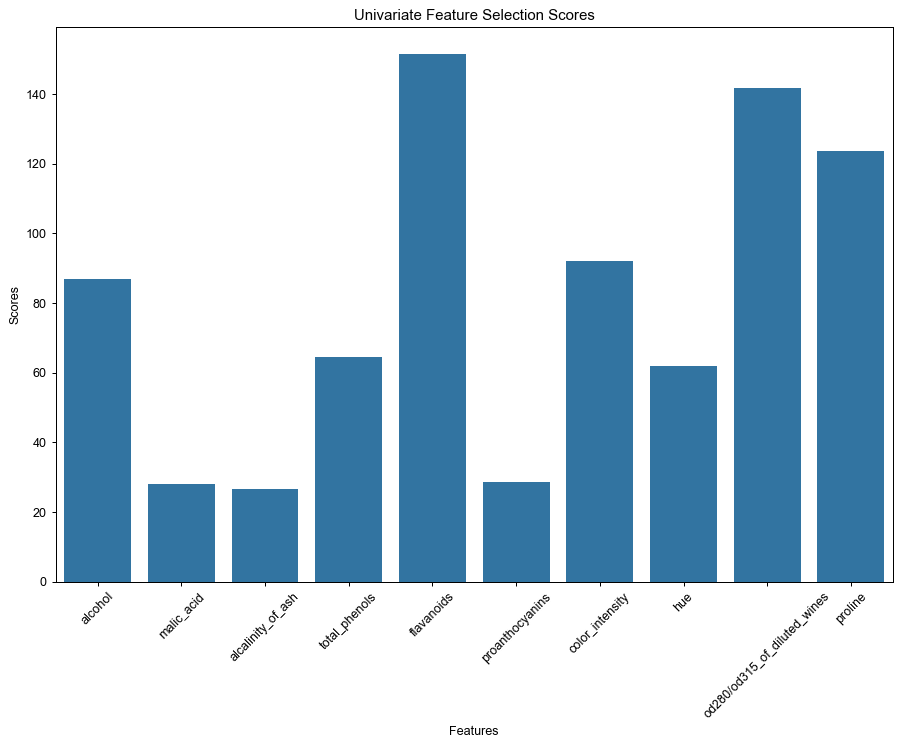

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Step 1: 加载葡萄酒数据集
# 这里我们使用sklearn自带的葡萄酒数据集（Wine dataset）
from sklearn.datasets import load_wine
data = load_wine()

# 将数据转换为DataFrame形式
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

# 查看数据的基本信息
print(X.head())
print(y.head())

# Step 2: 数据预处理
# 数据分为训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 标准化特征
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Step 3: 单变量特征选择（Univariate Feature Selection）
# 使用SelectKBest选择前10个最重要的特征
selector = SelectKBest(score_func=f_classif, k=10)
X_train_selected = selector.fit_transform(X_train_scaled, y_train)
X_test_selected = selector.transform(X_test_scaled)

# 查看选择的特征和它们的分数
selected_features = X.columns[selector.get_support()]
print("Selected Features: ", selected_features)

# Step 4: 可视化选择的特征
# 可视化前10个特征的分数
plt.figure(figsize=(12, 8))
sns.barplot(x=selected_features, y=selector.scores_[selector.get_support()])
plt.title('Univariate Feature Selection Scores')
plt.xlabel('Features')
plt.ylabel('Scores')
plt.xticks(rotation=45)
plt.show()

Classification Report:
               precision    recall  f1-score   support

           0       0.95      1.00      0.97        19
           1       1.00      0.95      0.98        21
           2       1.00      1.00      1.00        14

    accuracy                           0.98        54
   macro avg       0.98      0.98      0.98        54
weighted avg       0.98      0.98      0.98        54



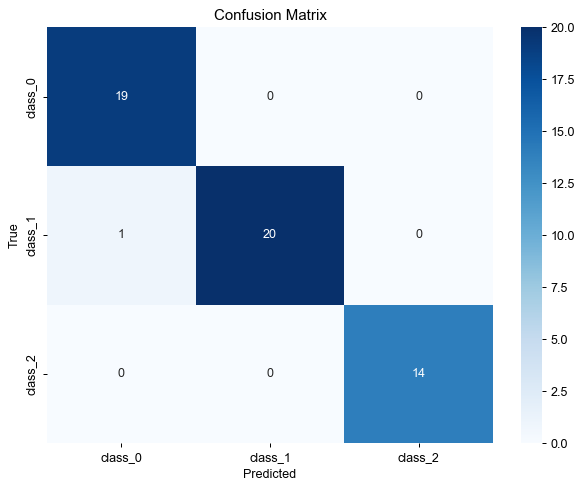

/opt/anaconda3/lib/python3.13/site-packages/sklearn/feature_selection/_univariate_selection.py:782: UserWarning: k=15 is greater than n_features=13. All the features will be returned.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/feature_selection/_univariate_selection.py:782: UserWarning: k=20 is greater than n_features=13. All the features will be returned.
  warnings.warn(


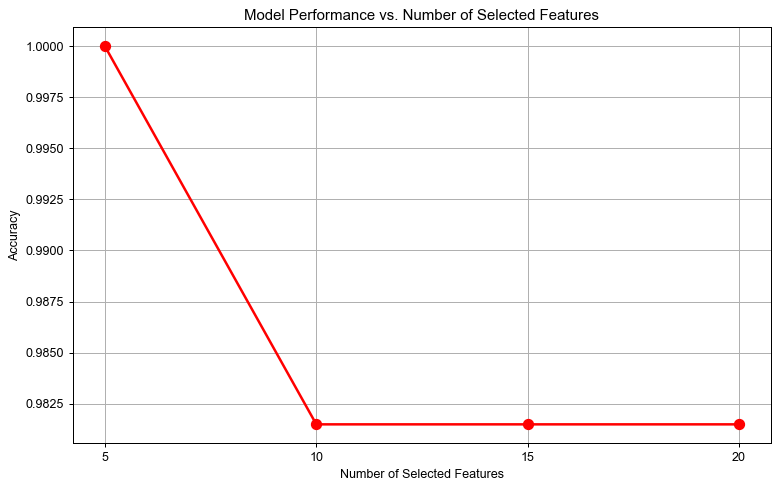

Best number of features: 5 with accuracy: 1.0000


In [3]:
# Step 5: 训练分类模型（Logistic Regression）
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_selected, y_train)

# Step 6: 评估模型性能
y_pred = model.predict(X_test_selected)

# 分类报告和混淆矩阵
print("Classification Report:\n", classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)

# 可视化混淆矩阵
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=data.target_names, yticklabels=data.target_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# Step 7: 优化：尝试不同数量的特征
# 选择不同数量的特征进行训练，并比较模型表现
k_values = [5, 10, 15, 20]
scores = []

for k in k_values:
    selector = SelectKBest(score_func=f_classif, k=k)
    X_train_selected = selector.fit_transform(X_train_scaled, y_train)
    X_test_selected = selector.transform(X_test_scaled)
    model.fit(X_train_selected, y_train)
    y_pred = model.predict(X_test_selected)
    score = model.score(X_test_selected, y_test)
    scores.append(score)

# 绘制模型性能随特征数量变化的图
plt.figure(figsize=(10, 6))
plt.plot(k_values, scores, marker='o', color='r', linestyle='-', linewidth=2, markersize=8)
plt.title('Model Performance vs. Number of Selected Features')
plt.xlabel('Number of Selected Features')
plt.ylabel('Accuracy')
plt.xticks(k_values)
plt.grid(True)
plt.show()

# Step 8: 结论和优化
best_k = k_values[np.argmax(scores)]
print(f"Best number of features: {best_k} with accuracy: {max(scores):.4f}")

#### 1. **加载和探索数据**

我们使用了`load_wine`函数从sklearn加载了葡萄酒数据集，这个数据集包含了13个特征，描述了不同葡萄酒的化学成分（如酒精、酸度、色度等），目标变量是葡萄酒的质量等级（分类变量，范围是0到2）。

使用`pandas`将数据转化为DataFrame格式，方便后续操作。

#### 2. **数据预处理**

在数据预处理阶段，我们首先将数据分为训练集和测试集（70%训练集，30%测试集）。然后，我们对特征进行标准化处理，使用`StandardScaler`将所有特征的均值调整为0，方差调整为1，这有助于提高模型的表现。

#### 3. **单变量特征选择**

单变量特征选择的核心是根据特征与目标变量的统计关系来选择最相关的特征。这里，我们使用`SelectKBest`，它通过F检验（F-test）来计算每个特征与目标变量之间的相关性，选择得分最高的特征。

选择了前10个最重要的特征，并输出了选择的特征名称。

#### 4. **可视化特征选择**

使用`seaborn`绘制了一个条形图，展示了选择的特征及其相应的得分。图表中，每个条形的长度表示该特征的重要性得分，从中可以直观地看到哪些特征对预测葡萄酒质量最有用。

![原文参考图，当前结果见代码输出](attachments/img_001.png)

#### 5. **训练模型**

我们使用逻辑回归模型对选择的特征进行训练，并评估其在测试集上的表现。通过`classification_report`可以查看各个类别的精确度、召回率和F1-score。

此外，绘制了混淆矩阵，通过颜色深浅显示分类模型在各个类别上的预测效果。

![原文参考图，当前结果见代码输出](attachments/img_002.png)

#### 6. **优化：选择不同数量的特征**

我们尝试了不同数量的特征（5个、10个、15个和20个），并比较了它们对模型性能的影响。通过绘制模型性能（准确率）随特征数量变化的图表，可以清晰地看到，选择的特征越多，模型的性能并不是一定提高，可能会出现过拟合现象。

![原文参考图，当前结果见代码输出](attachments/img_003.png)

#### 7. **优化结论**

根据优化结果，我们可以发现，当选择的特征数量为10时，模型表现最好，准确率最高。因此，选择最相关的特征数目对模型性能至关重要。

### 案例总结

**单变量特征选择**是一种有效的特征选择方法，可以帮助我们去除无关特征，减少模型的复杂性，提高训练效率。

通过**F检验**、**卡方检验**等方法，我们能够选择出与目标变量最相关的特征。

通过优化不同数量的特征，我们发现选择最相关的特征数量对模型表现至关重要，过多或过少都会影响模型的准确性。

最终，单变量特征选择不仅帮助我们提高了模型性能，还通过合理选择特征数量，避免了过拟合，从而优化了机器学习模型。

## 模型分析

### 优缺点分析

**优点：**

1. **简单易懂**：单变量特征选择方法基于每个特征与目标变量的相关性评估，可以通过统计检验（如卡方检验、F检验、互信息等）非常直观地选择出最重要的特征。由于其数学原理简单，因此对于初学者来说，是一种很好的特征选择入门方法。
2. **计算效率高**：单变量特征选择通过逐个评估特征与目标之间的关系，通常计算开销较低，适合于中小型数据集。它不涉及复杂的模型训练，且可以快速得出结果。
3. **有效性强**：当数据的特征数量较多、且特征之间不存在线性相关性时，单变量特征选择能通过简单的统计检验有效识别出与目标变量最相关的特征，从而避免了冗余特征对模型训练的影响。
4. **适用性广**：该方法适用于回归问题（通过F检验等）和分类问题（通过卡方检验等）。特别是在特征数量非常大的时候，它能够帮助快速筛选出有用的特征。

**缺点：**

1. **忽略特征之间的相互关系**：单变量特征选择方法是独立地对每个特征进行选择，它没有考虑特征之间可能存在的相关性或交互作用。即使两个特征分别对目标变量有较强的影响，但如果它们之间高度相关，单独使用单变量特征选择可能会导致它们中的一个被丢弃。
2. **无法处理复杂非线性关系**：单变量特征选择主要基于线性关系（如F检验依赖于方差分析、卡方检验基于频率分布），对于具有复杂非线性关系的数据，可能无法很好地识别出重要特征。
3. **过度简化模型**：单变量特征选择的简化特性可能会在某些情况下损失重要的高阶交互信息。它只是根据每个特征的独立性来选择特征，忽视了特征间的潜在复杂关系。
4. **可能会丢失信息**：当使用卡方检验等方法进行特征选择时，过于依赖统计显著性可能会导致一些有潜力的特征被丢弃。例如，在一些实际应用中，特征之间的微小变化可能对模型有很大帮助，但单独查看每个特征时，这些变化可能不会显著，导致这些特征被舍弃。

### 与相似特征选择方法的对比

| 特征选择方法 | 选择依据 | 优点 | 缺点 | 适用场景 |
|-|-|-|-|-|
| **单变量特征选择** | 通过统计测试（如卡方、F检验等）选择与目标变量关系最强的特征 | 简单、快速、直观，计算开销小；适合数据量不大，特征不多的情况 | 忽略特征间相互关系，不能捕捉到复杂的交互作用或非线性关系 | 特征数量较多，且特征间关系较简单的任务（如分类或回归问题） |
| **递归特征消除（RFE）** | 通过训练模型逐步去除最不重要的特征 | 能考虑特征间的相关性和交互作用，逐步优化选择的特征集；结果可能更精确 | 计算开销较大，训练多个模型，适用于特征和数据量较小的情况 | 特征间有复杂关系且需要较高精度的任务 |
| **L1正则化（Lasso回归）** | 通过引入L1正则化对特征进行惩罚，从而驱动某些特征的系数变为零 | 既能做特征选择，又能防止过拟合；适用于高维数据 | 对于高度相关的特征，可能会随机选择其中一个并将其系数归零 | 特征维度非常高，且希望能进行特征筛选与模型正则化的任务 |
| **基于树的特征选择（如决策树、随机森林）** | 通过决策树模型（如随机森林）评估特征的重要性 | 能捕捉到特征间的非线性关系，结果较为稳定；适用于复杂问题 | 模型训练较慢，可能过拟合，不能处理所有类型的特征数据 | 特征间关系复杂且任务为回归或分类任务（特别是非线性数据） |
| **互信息** | 通过计算特征与目标变量之间的信息共享程度选择最重要的特征 | 能捕捉到特征与目标之间的非线性关系；适用于分类问题 | 计算开销较大，对于高维数据可能不适用；只能捕捉到特征之间的相关性 | 特征与目标之间存在非线性关系时 |

### 在什么情况下选择单变量特征选择方法，何时考虑其他方法

#### 适合使用单变量特征选择的方法：

1. **特征间独立且数量较少时**：如果数据集中的特征之间独立，且特征的数量相对较少（如几十个特征），单变量特征选择方法是非常有效的。它通过直接的统计检验，快速、简便地筛选出对目标变量最相关的特征。在这种情况下，使用这种方法可以快速获得模型训练所需的特征，减少计算开销。
2. **线性关系较强的任务**：如果目标变量与特征之间具有较强的线性关系（例如，F检验适用于方差分析），那么单变量特征选择方法尤其有效。在这些场景中，统计测试能够准确评估每个特征与目标变量之间的关系，从而选出最有效的特征。
3. **高效性要求较高的任务**：如果任务需要快速处理，且数据量不大，单变量特征选择能够提供高效的特征选择过程。它通常在机器学习的初步分析阶段使用，帮助快速剔除不相关的特征，便于后续更复杂的建模。

#### 考虑其他特征选择方法的情况：

1. **特征间存在强相关性或交互作用时**：当特征之间存在强相关性或交互作用时，单变量特征选择方法可能无法准确识别出最有效的特征。例如，当两个特征分别与目标变量有较强的关联，但它们之间的关系可能导致其中一个被错误地剔除。在这种情况下，递归特征消除（RFE）或基于树的特征选择（如随机森林）可能是更好的选择，因为它们能够考虑特征之间的相关性和交互作用。
2. **数据集特征维度非常高时**：当数据集的特征维度非常高（如数千个特征）时，单变量特征选择的效果可能不如L1正则化（Lasso回归）或者树模型。这些方法可以同时执行特征选择和模型正则化，帮助减轻高维度数据带来的问题。
3. **非线性关系较强时**：单变量特征选择方法主要依赖于线性关系（如F检验的方差分析），对于特征与目标之间的非线性关系，可能无法有效识别。在这种情况下，基于树的特征选择方法或互信息方法可以更好地捕捉非线性特征之间的关系。
4. **模型性能要求较高时**：如果任务对模型的性能要求较高，且希望进行更精确的特征选择，可以考虑使用递归特征消除（RFE）或基于树的特征选择方法。这些方法通过训练模型评估特征的重要性，可以获得更精确的特征子集。

## 总结

单变量特征选择方法因其简单、快速、计算效率高，适用于特征之间独立、数据规模较小的任务。但对于复杂的任务（如特征间高度相关、非线性关系显著等），可能需要采用更为复杂的特征选择方法（如RFE、Lasso、树模型等）。在选择特征选择方法时，我们的实验中，应根据数据集的特点和任务需求来决定最合适的方法。